In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import urllib.request
import zipfile


In [20]:
from pathlib import Path
import urllib.request
import zipfile

DATA_URL = "https://files.grouplens.org/datasets/movielens/ml-1m.zip"
DATA_DIR = Path("data") / "ml-1m"
ZIP_PATH = Path("data") / "ml-1m.zip"

kaggle_candidates = list(Path("/kaggle/input").rglob("ratings.dat")) if Path("/kaggle/input").exists() else []
if kaggle_candidates:
    ratings_path = kaggle_candidates[0]
    items_path = ratings_path.parent / "movies.dat"
else:
    if not (DATA_DIR / "ratings.dat").exists():
        DATA_DIR.parent.mkdir(parents=True, exist_ok=True)
        if not ZIP_PATH.exists():
            urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
        with zipfile.ZipFile(ZIP_PATH, "r") as zf:
            zf.extractall(DATA_DIR.parent)

    ratings_path = DATA_DIR / "ratings.dat"
    items_path = DATA_DIR / "movies.dat"

ratings = pd.read_csv(
    ratings_path,
    sep="::",
    names=["user_id", "item_id", "rating", "timestamp"],
    engine="python",
    encoding="latin-1",
)

items = pd.read_csv(
    items_path,
    sep="::",
    names=["item_id", "title", "genres"],
    usecols=[0, 1],
    engine="python",
    encoding="latin-1",
)

ratings.head()


,user_id,item_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [21]:
print("Пользователей:", ratings.user_id.nunique())
print("Предметов:", ratings.item_id.nunique())
print("Всего взаимодействий:", len(ratings))

user_counts = ratings.groupby("user_id").size()
item_counts = ratings.groupby("item_id").size()

print("Сколько в среднем предметов у пользователя:", round(user_counts.mean(), 2))
print("Медиана предметов у пользователя:", int(user_counts.median()))
print("Сколько в среднем пользователей у предмета:", round(item_counts.mean(), 2))
print("Медиана пользователей у предмета:", int(item_counts.median()))

print("Распределение рейтингов:")
print(ratings.rating.value_counts().sort_index())

Пользователей: 6040
Предметов: 3706
Всего взаимодействий: 1000209
Сколько в среднем предметов у пользователя: 165.6
Медиана предметов у пользователя: 96
Сколько в среднем пользователей у предмета: 269.89
Медиана пользователей у предмета: 123
Распределение рейтингов:
rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64


In [22]:
min_interactions = 2

user_ok = user_counts[user_counts >= min_interactions].index
item_ok = item_counts[item_counts >= min_interactions].index

filtered = ratings[ratings.user_id.isin(user_ok) & ratings.item_id.isin(item_ok)].copy()

print("Было:", len(ratings), "| Стало:", len(filtered))
print("Пользователей после очистки:", filtered.user_id.nunique())
print("Предметов после очистки:", filtered.item_id.nunique())

Было: 1000209 | Стало: 1000095
Пользователей после очистки: 6040
Предметов после очистки: 3592


In [23]:
filtered = filtered.sort_values(["user_id", "timestamp"])

last_idx = filtered.groupby("user_id").tail(1).index

test = filtered.loc[last_idx].copy()
train = filtered.drop(index=last_idx).copy()

print("Train:", len(train), "| Test:", len(test))

Train: 994055 | Test: 6040


In [24]:
train_seen = train.groupby("user_id")["item_id"].apply(set).to_dict()

test_items = test.groupby("user_id")["item_id"].apply(set).to_dict()

all_items = set(train.item_id.unique())

In [25]:
item_stats = train.groupby("item_id").agg(
    mean_rating=("rating", "mean"),
    count=("rating", "size"),
)

item_stats = item_stats.sort_values(["mean_rating", "count"], ascending=False)
popular_items = item_stats.index.tolist()

In [26]:
def precision_at_k(recommended, relevant, k):
    rec_k = recommended[:k]
    if not rec_k:
        return 0.0
    return len(set(rec_k) & relevant) / k


def recall_at_k(recommended, relevant, k):
    if not relevant:
        return 0.0
    rec_k = recommended[:k]
    return len(set(rec_k) & relevant) / len(relevant)


def average_precision_at_k(recommended, relevant, k):
    rec_k = recommended[:k]
    hits = 0
    score = 0.0
    for i, item in enumerate(rec_k, start=1):
        if item in relevant:
            hits += 1
            score += hits / i
    if not relevant:
        return 0.0
    return score / min(len(relevant), k)


def ndcg_at_k(recommended, relevant, k):
    rec_k = recommended[:k]
    dcg = 0.0
    for i, item in enumerate(rec_k, start=1):
        if item in relevant:
            dcg += 1.0 / np.log2(i + 1)
    idcg = sum(1.0 / np.log2(i + 1) for i in range(1, min(len(relevant), k) + 1))
    return dcg / idcg if idcg > 0 else 0.0


def evaluate(recommender, users, k=10):
    precisions, recalls, maps, ndcgs = [], [], [], []
    rec_lists = []

    for user in users:
        relevant = test_items.get(user, set())
        recommended = recommender(user)
        rec_lists.append(recommended[:k])

        precisions.append(precision_at_k(recommended, relevant, k))
        recalls.append(recall_at_k(recommended, relevant, k))
        maps.append(average_precision_at_k(recommended, relevant, k))
        ndcgs.append(ndcg_at_k(recommended, relevant, k))

    all_rec_items = set(item for rec in rec_lists for item in rec)
    coverage = len(all_rec_items) / len(all_items) if all_items else 0.0

    if len(rec_lists) > 1:
        sims = []
        for i in range(len(rec_lists)):
            for j in range(i + 1, len(rec_lists)):
                a, b = set(rec_lists[i]), set(rec_lists[j])
                if not a and not b:
                    sims.append(1.0)
                else:
                    sims.append(len(a & b) / len(a | b))
        personalization = 1.0 - float(np.mean(sims))
    else:
        personalization = 0.0

    return {
        "precision@k": float(np.mean(precisions)),
        "recall@k": float(np.mean(recalls)),
        "map@k": float(np.mean(maps)),
        "ndcg@k": float(np.mean(ndcgs)),
        "coverage": coverage,
        "personalization": personalization,
    }

In [27]:
K = 10

def popular_recommender(user_id):
    seen = train_seen.get(user_id, set())
    return [item for item in popular_items if item not in seen]

users_in_test = test.user_id.unique().tolist()

baseline_metrics = evaluate(popular_recommender, users_in_test, k=K)
print("Baseline metrics:")
print(baseline_metrics)

Baseline metrics:
{'precision@k': 0.0007284768211920531, 'recall@k': 0.00728476821192053, 'map@k': 0.0009077052454535898, 'ndcg@k': 0.0022924251075571757, 'coverage': 0.005567928730512249, 'personalization': 0.23511977131586104}


In [28]:
user_ids = train.user_id.unique()
item_ids = train.item_id.unique()

user_to_idx = {u: i for i, u in enumerate(user_ids)}
item_to_idx = {m: i for i, m in enumerate(item_ids)}

train_idx = train.copy()
train_idx["user_idx"] = train_idx.user_id.map(user_to_idx)
train_idx["item_idx"] = train_idx.item_id.map(item_to_idx)

test_idx = test[test.user_id.isin(user_to_idx.keys()) & test.item_id.isin(item_to_idx.keys())].copy()

In [29]:
class RatingsDataset(Dataset):
    def __init__(self, df):
        self.users = df.user_idx.values.astype(np.int64)
        self.items = df.item_idx.values.astype(np.int64)
        self.ratings = df.rating.values.astype(np.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]


train_ds = RatingsDataset(train_idx)
train_loader = DataLoader(train_ds, batch_size=1024, shuffle=True)

In [30]:
class MFModel(nn.Module):
    def __init__(self, n_users, n_items, n_factors=32):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, n_factors)
        self.item_emb = nn.Embedding(n_items, n_factors)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)

        nn.init.normal_(self.user_emb.weight, std=0.1)
        nn.init.normal_(self.item_emb.weight, std=0.1)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def forward(self, user_idx, item_idx):
        dot = (self.user_emb(user_idx) * self.item_emb(item_idx)).sum(dim=1)
        bias = self.user_bias(user_idx).squeeze(1) + self.item_bias(item_idx).squeeze(1)
        return dot + bias


device = torch.device("cuda")
model = MFModel(len(user_to_idx), len(item_to_idx), n_factors=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)
loss_fn = nn.MSELoss()

In [31]:
@torch.no_grad()
def mf_recommender(user_id):
    if user_id not in user_to_idx:
        return []

    user_idx = torch.tensor([user_to_idx[user_id]], device=device)
    user_vec = model.user_emb(user_idx)
    item_vecs = model.item_emb.weight
    scores = (user_vec * item_vecs).sum(dim=1)
    scores += model.item_bias.weight.squeeze(1)
    scores += model.user_bias(user_idx).squeeze(1)

    scores = scores.cpu().numpy()

    seen = train_seen.get(user_id, set())
    seen_idx = {item_to_idx[i] for i in seen if i in item_to_idx}

    ranked = np.argsort(-scores)
    result = []
    for idx in ranked:
        item_id = item_ids[idx]
        if idx not in seen_idx:
            result.append(item_id)
    return result

In [32]:
def evaluate_mf(k=10):
    return evaluate(mf_recommender, users_in_test, k=k)

n_epochs = 15
patience = 3
best_ndcg = -1.0
best_state = None
no_improve = 0

for epoch in range(1, n_epochs + 1):
    model.train()
    losses = []
    for user_idx, item_idx, rating in train_loader:
        user_idx = user_idx.to(device)
        item_idx = item_idx.to(device)
        rating = rating.to(device)

        pred = model(user_idx, item_idx)
        loss = loss_fn(pred, rating)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    model.eval()
    metrics = evaluate_mf(k=K)

    print(
        f"Epoch {epoch:02d} | loss={np.mean(losses):.4f} | "
        f"precision@{K}={metrics['precision@k']:.4f} | "
        f"recall@{K}={metrics['recall@k']:.4f} | "
        f"ndcg@{K}={metrics['ndcg@k']:.4f}"
    )

    if metrics['ndcg@k'] > best_ndcg:
        best_ndcg = metrics['ndcg@k']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print("качество перестало расти")
            break

if best_state is not None:
    model.load_state_dict(best_state)


Epoch 01 | loss=12.3343 | precision@10=0.0025 | recall@10=0.0247 | ndcg@10=0.0122
Epoch 02 | loss=7.3859 | precision@10=0.0038 | recall@10=0.0377 | ndcg@10=0.0185
Epoch 03 | loss=1.8586 | precision@10=0.0030 | recall@10=0.0301 | ndcg@10=0.0147
Epoch 04 | loss=1.0413 | precision@10=0.0021 | recall@10=0.0209 | ndcg@10=0.0098
Epoch 05 | loss=0.8907 | precision@10=0.0016 | recall@10=0.0157 | ndcg@10=0.0083
качество перестало расти


In [33]:
final_metrics = evaluate_mf(k=K)

print("Baseline:", baseline_metrics)
print("MF Model:", final_metrics)

Baseline: {'precision@k': 0.0007284768211920531, 'recall@k': 0.00728476821192053, 'map@k': 0.0009077052454535898, 'ndcg@k': 0.0022924251075571757, 'coverage': 0.005567928730512249, 'personalization': 0.23511977131586104}
MF Model: {'precision@k': 0.003774834437086093, 'recall@k': 0.03774834437086093, 'map@k': 0.012697558604015557, 'ndcg@k': 0.01846406974400355, 'coverage': 0.05373051224944321, 'personalization': 0.7979048829431818}


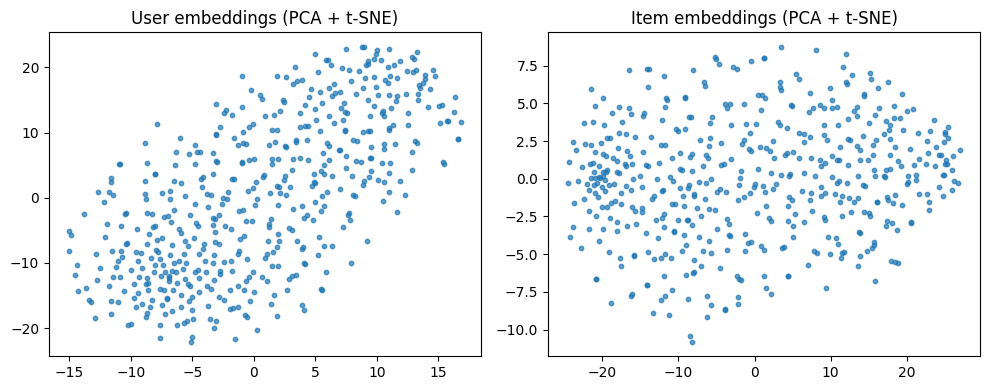

In [ ]:
np.random.seed(42)
user_sample = np.random.choice(len(user_to_idx), size=min(500, len(user_to_idx)), replace=False)
item_sample = np.random.choice(len(item_to_idx), size=min(500, len(item_to_idx)), replace=False)

user_emb = model.user_emb.weight.detach().cpu().numpy()[user_sample]
item_emb = model.item_emb.weight.detach().cpu().numpy()[item_sample]

pca = PCA(n_components=20, random_state=42)
user_emb_pca = pca.fit_transform(user_emb)
item_emb_pca = pca.fit_transform(item_emb)

user_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(user_emb_pca)
item_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(item_emb_pca)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(user_2d[:, 0], user_2d[:, 1], s=10, alpha=0.7)
plt.title("User embeddings (PCA + t-SNE)")

plt.subplot(1, 2, 2)
plt.scatter(item_2d[:, 0], item_2d[:, 1], s=10, alpha=0.7)
plt.title("Item embeddings (PCA + t-SNE)")

plt.tight_layout()
plt.show()


In [35]:
sample_users = users_in_test[:5]
print("5 пользователей и их топ-5 рекомендаций")

for u in sample_users:
    recs = mf_recommender(u)[:5]
    titles = items[items.item_id.isin(recs)].set_index("item_id").loc[recs]["title"].tolist()
    print(f"User {u}:", titles)

5 пользователей и их топ-5 рекомендаций
User 1: ['Matrix, The (1999)', 'Groundhog Day (1993)', 'American Beauty (1999)', 'Star Wars: Episode V - The Empire Strikes Back (1980)', 'L.A. Confidential (1997)']
User 2: ['Star Wars: Episode IV - A New Hope (1977)', 'L.A. Confidential (1997)', 'Back to the Future (1985)', 'Sixth Sense, The (1999)', "Schindler's List (1993)"]
User 3: ['Matrix, The (1999)', 'Terminator, The (1984)', 'Saving Private Ryan (1998)', 'Terminator 2: Judgment Day (1991)', 'Usual Suspects, The (1995)']
User 4: ['American Beauty (1999)', 'Matrix, The (1999)', 'Pulp Fiction (1994)', 'Back to the Future (1985)', 'Terminator 2: Judgment Day (1991)']
User 5: ['Star Wars: Episode IV - A New Hope (1977)', 'Star Wars: Episode V - The Empire Strikes Back (1980)', "Schindler's List (1993)", 'Godfather, The (1972)', 'Raiders of the Lost Ark (1981)']
